# CSR Setup (SD)

A data analysis of the use case 'sharing dependencies between remotes' on the CSR setup. 

CSR = Client Side Rendering using Angular 18.3, Java 21, Apache Wicket 10 and Native Federation

In [16]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats

plt.rcParams.update({'font.size': 14})
pd.set_option('display.float_format', lambda x: '%.2f' % x)
path = '../../../../playwright/results/core-web-vitals/testrun-9/'

def graph_row(plot_func, datasets, height=3, width=20):
    cols = len(datasets)
    fig, axes = plt.subplots(ncols=cols, figsize=(width, height))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    for x, (name, dataset) in enumerate(datasets.items()):
        plot_func(dataset, axes[x], idx=x)
        axes[x].set_title(name)
    return plt

def graph_grid(plot_func, datasets, features, height=4, width=20):
    fig, axes = plt.subplots(ncols=len(datasets), nrows=len(features), figsize=(width, height*len(features)))
    plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
    for y, f in enumerate(features):
        for x, (name, dataset) in enumerate(datasets.items()):
            plot_func(dataset, axes[y,x], idx=x+y, d=name, f=f)
            axes[y,x].set_title(name)
    return plt

def detect_outliers(_df, _features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(_df[_features])
    return outliers == 1

In [17]:
features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config','nf:loaded']

dirty_dfs = {
    'default': pd.read_csv(f'{path}results-csr-sd.csv', sep=',')[5:],
    'throttled': pd.read_csv(f'{path}results-csr-sd-throttled.csv', sep=',')[5:],
    'heavy': pd.read_csv(f'{path}results-csr-sd-throttled-heavy.csv', sep=',')[5:],
}

## Dataset cleanup + oulier removal

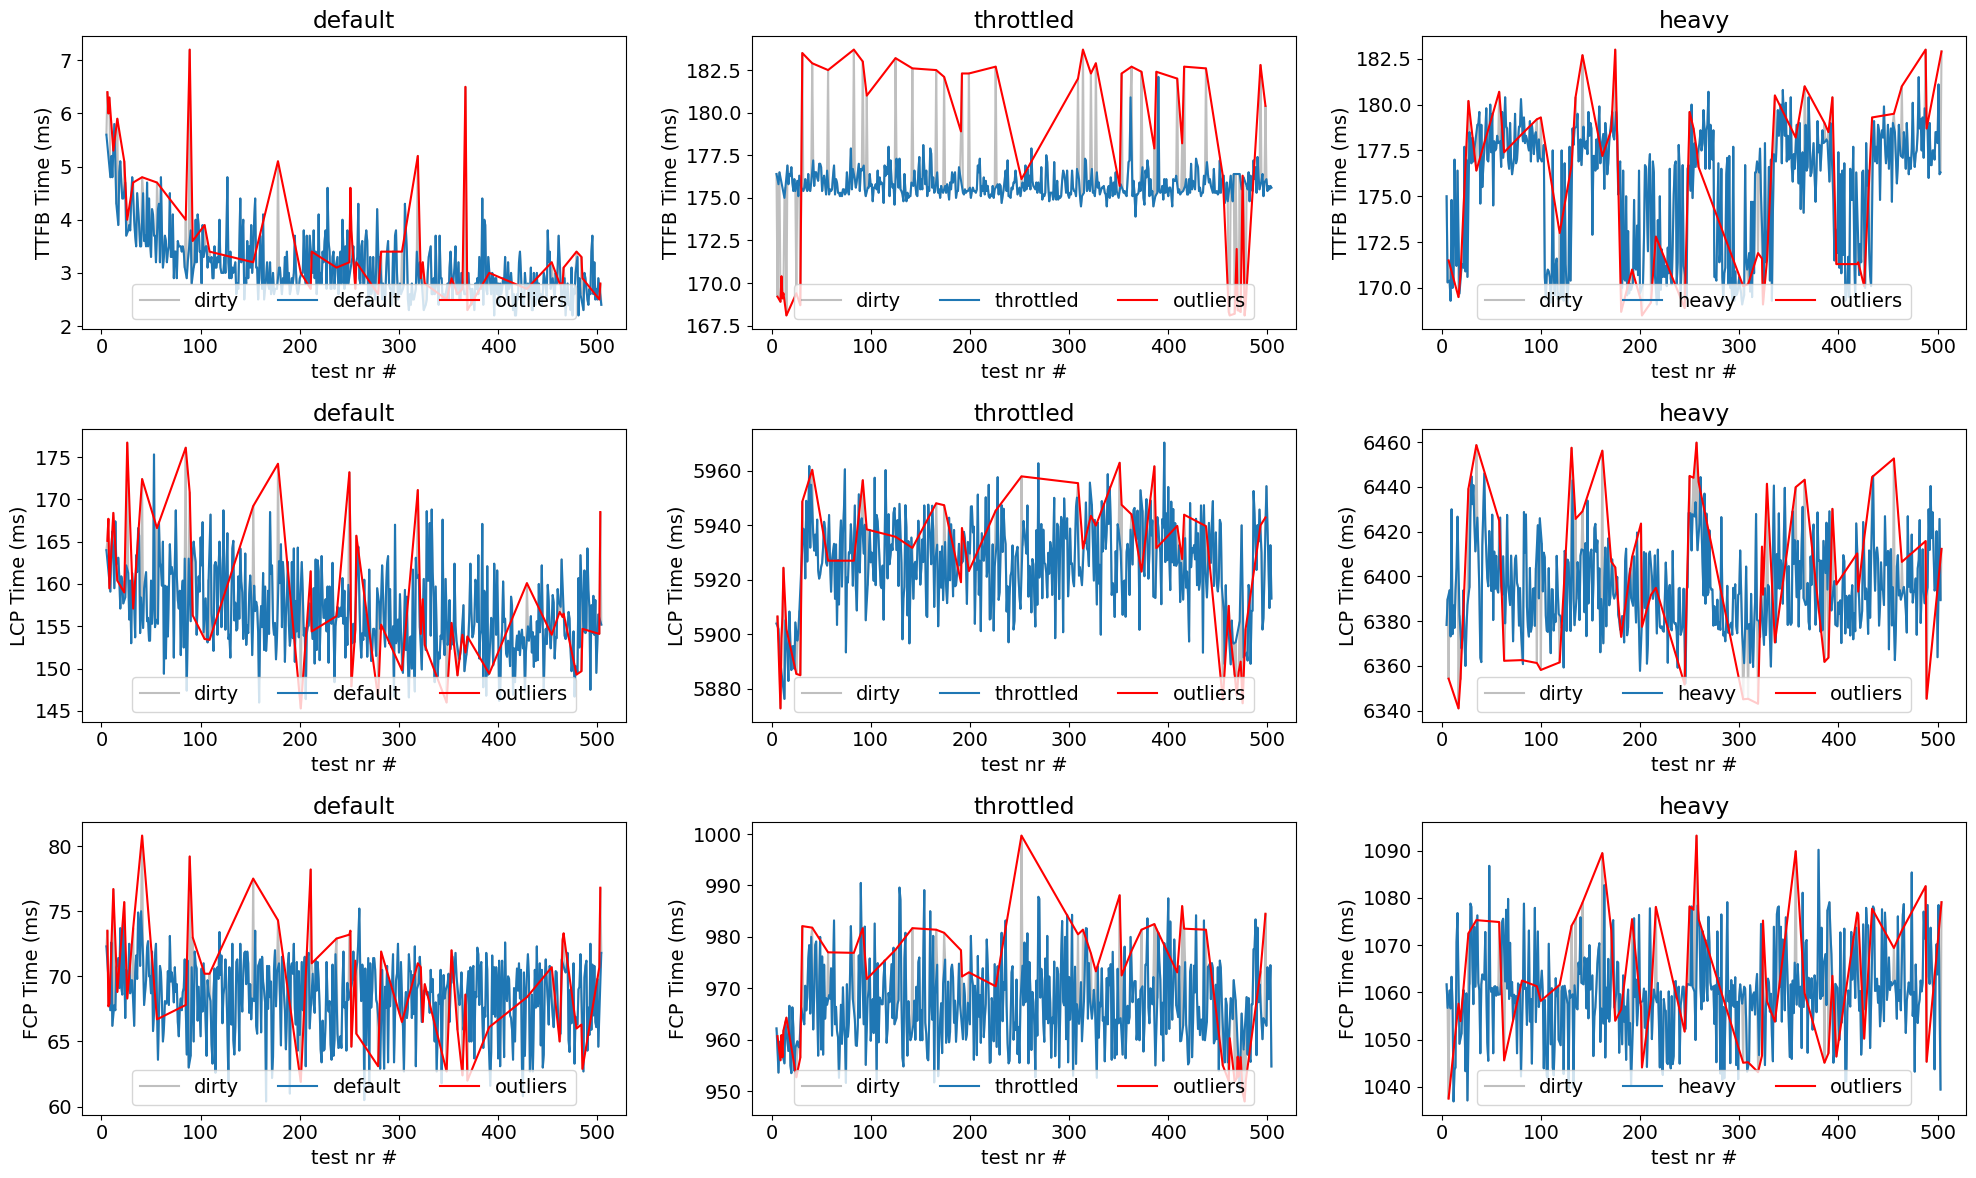

In [18]:
masks = {}
dfs = {}
target_features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb']

for name, _df in dirty_dfs.items():
    mask = detect_outliers(_df, target_features)
    masks[name] = mask
    dfs[name] = _df[mask].copy()

def plot_outliers(_df, axes, idx, d, f):
    axes.plot(_df[f], label='dirty', color='gray', alpha=0.5)
    axes.plot(_df[f][masks[d]], label=d)
    axes.plot(_df[f][~masks[d]], label='outliers', color='red')

    axes.set_title(d)
    axes.set_ylabel(f'{f.upper()} Time (ms)') 
    axes.set_xlabel('test nr #') 
    axes.legend(loc='lower center', ncols=3)

graph_grid(plot_outliers, dirty_dfs, features=['ttfb','lcp', 'fcp'])
plt.tight_layout()
plt.show()

## Performance over time

x = Cycles over time (sequential)

y = Performance marks over time (each marking the timestamp when finished)

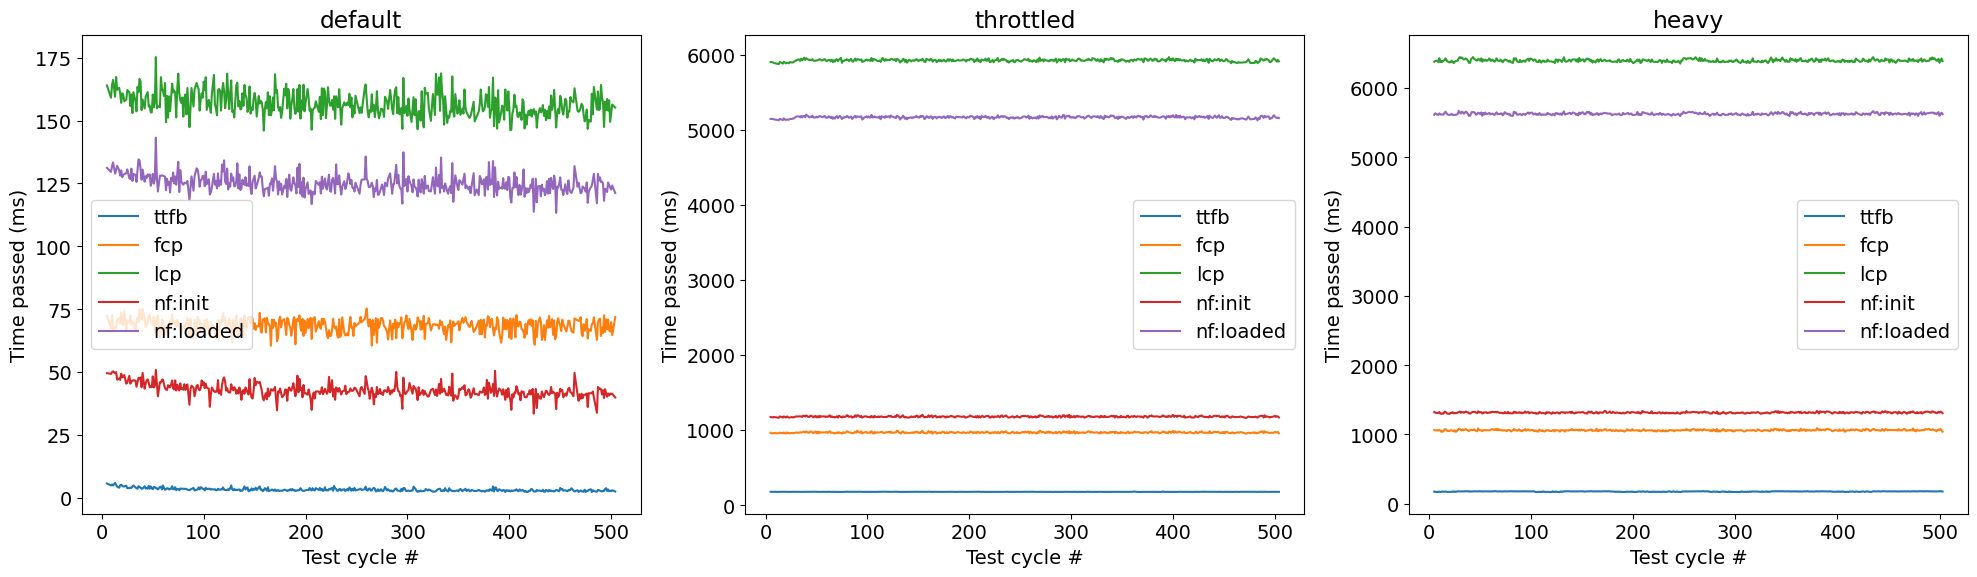

In [19]:
def plot_line(dataset, loc, idx):
    for t in ['ttfb', 'fcp', 'lcp', 'nf:init', 'nf:loaded']:
        loc.plot(dataset[t], label=t)
    loc.set_xlabel('Test cycle #')
    loc.set_ylabel('Time passed (ms)')
    loc.legend()

graph_row(plot_line, dfs, height=6)
plt.tight_layout()
plt.show()

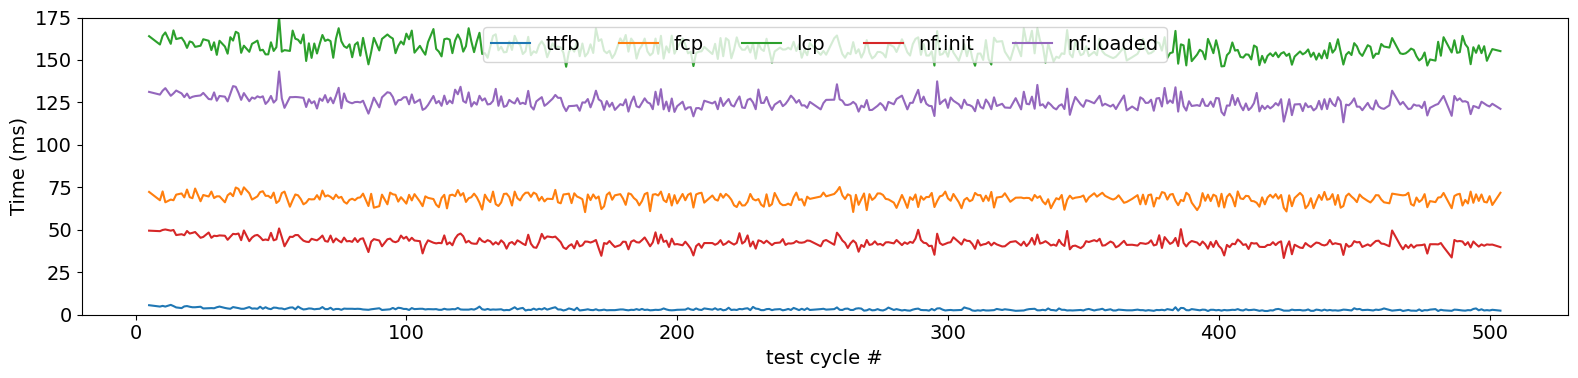

In [20]:
plt.figure(figsize=(16, 4))

for t in ['ttfb', 'fcp', 'lcp', 'nf:init', 'nf:loaded']:
    plt.plot(dfs['default'][t], label=t)
plt.xlabel('test cycle #')
plt.ylabel('Time (ms)')
plt.legend(loc='upper center', ncols=5)
plt.ylim(bottom=0, top=175)
plt.margins(y=0.1)

plt.tight_layout()
plt.show()

## Comparison of JavaScript performance between contexts. 

tbt = total blocking time

longestTask = duration of the longest task. 

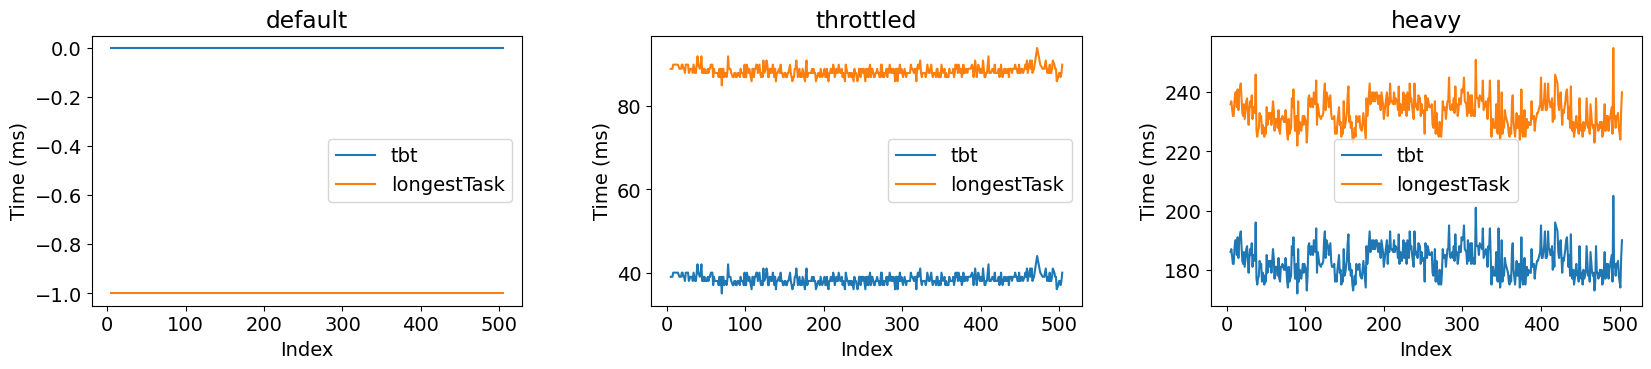

In [21]:
def plot_line(dataset, loc, idx):
    for t in ['tbt', 'longestTask']:
        loc.plot(dataset[t], label=t)
    loc.set_xlabel('Index')
    loc.set_ylabel('Time (ms)')
    loc.legend()

graph_row(plot_line, dfs)
plt.show()

## 75th quantile of all performance metrics

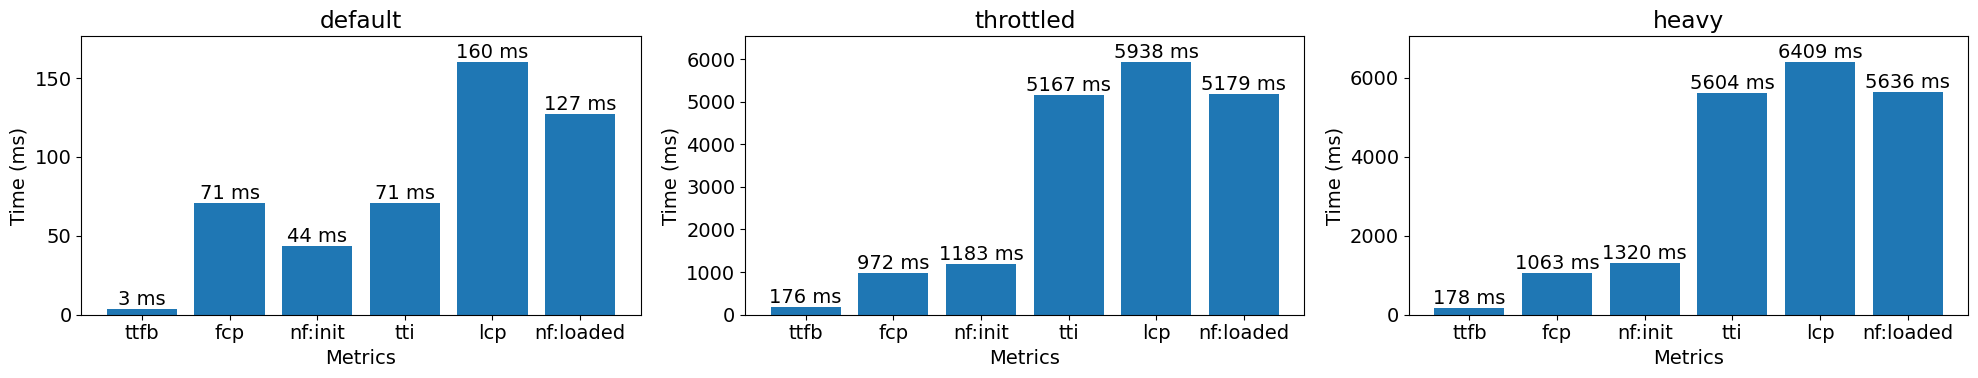

In [22]:
def plot_timeline_bars(dataset, loc, idx):
    metrics = ['ttfb', 'fcp', 'nf:init', 'tti', 'lcp', 'nf:loaded']
    quantiles = [dataset[t].quantile(0.75) for t in metrics]
    bars = loc.bar(metrics, quantiles, label='75th percentile')
    loc.set_xlabel('Metrics')
    loc.set_ylabel('Time (ms)')
    
    for bar in bars:
        height = bar.get_height()
        loc.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.0f} ms', ha='center', va='bottom')
    
    loc.set_ylim(0, max(quantiles) * 1.1)

graph_row(plot_timeline_bars, dfs, height=4)
plt.tight_layout()
plt.show()

In [23]:
dfs['default'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,255.78,8.27,65.00,156.67,68.45,3.13,0.00,68.45,0.00,-1.00,42.67,49.06,125.01,NaN
std,142.66,1.25,3.59,4.85,2.83,0.61,0.00,2.83,0.00,0.00,2.69,3.16,3.61,NaN
min,6.00,6.00,56.00,146.00,60.40,2.20,0.00,60.40,0.00,-1.00,33.40,38.50,113.30,NaN
25%,133.25,8.00,63.00,153.50,66.60,2.70,0.00,66.60,0.00,-1.00,41.10,47.10,122.73,NaN
50%,254.50,8.00,65.00,155.60,68.80,3.00,0.00,68.80,0.00,-1.00,42.40,48.65,124.65,NaN
75%,381.75,9.00,67.00,160.38,70.70,3.40,0.00,70.70,0.00,-1.00,43.80,50.50,127.20,NaN
max,505.00,17.00,82.00,175.30,75.20,5.80,0.00,75.20,0.00,-1.00,50.80,61.20,143.20,NaN


In [24]:
dfs['throttled'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,253.79,170.44,5174.01,5926.64,967.03,175.79,38.41,5156.82,1.00,88.41,1178.45,1562.63,5168.20,NaN
std,140.44,0.87,14.01,15.75,7.95,0.78,1.18,13.87,0.00,1.18,8.41,10.92,13.91,NaN
min,6.00,168.00,5132.00,5876.20,950.40,173.90,35.00,5115.80,1.00,85.00,1160.50,1530.30,5126.70,NaN
25%,133.25,170.00,5166.00,5917.42,960.83,175.30,38.00,5148.70,1.00,88.00,1173.30,1557.72,5160.25,NaN
50%,253.00,170.00,5175.00,5927.05,966.90,175.60,38.00,5157.40,1.00,88.00,1179.50,1565.40,5169.25,NaN
75%,372.75,171.00,5184.00,5938.30,972.28,176.20,39.00,5167.20,1.00,89.00,1182.67,1571.00,5178.68,NaN
max,505.00,177.00,5209.00,5970.40,990.50,182.10,44.00,5191.00,1.00,94.00,1203.70,1587.90,5202.20,NaN


In [25]:
dfs['heavy'].describe()

,idx,navTime,totalTime,lcp,fcp,ttfb,tbt,tti,longTasks,longestTask,nf:init,nf:config,nf:loaded,error
count,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,450.00,0.00
mean,255.69,178.46,5640.48,6395.25,1060.06,175.50,183.11,5594.86,2.00,233.11,1314.66,1699.92,5626.55,NaN
std,144.58,3.57,14.28,18.84,9.56,3.37,5.17,13.92,0.00,5.17,8.87,11.54,14.28,NaN
min,6.00,171.00,5608.00,6352.30,1036.90,169.10,172.00,5558.90,2.00,222.00,1295.70,1669.80,5593.90,NaN
25%,129.25,175.00,5630.00,6378.92,1055.82,171.80,179.00,5584.20,2.00,229.00,1308.62,1691.73,5616.10,NaN
50%,256.50,180.00,5639.00,6393.65,1060.20,176.80,183.00,5594.30,2.00,233.00,1313.85,1700.00,5624.90,NaN
75%,379.75,181.00,5650.00,6409.28,1063.08,178.00,187.00,5604.40,2.00,237.00,1320.08,1707.97,5636.05,NaN
max,504.00,185.00,5682.00,6446.00,1090.20,181.50,205.00,5638.50,2.00,255.00,1339.90,1732.70,5669.20,NaN


## Performance difference First Contentful Paint (75th quantile)

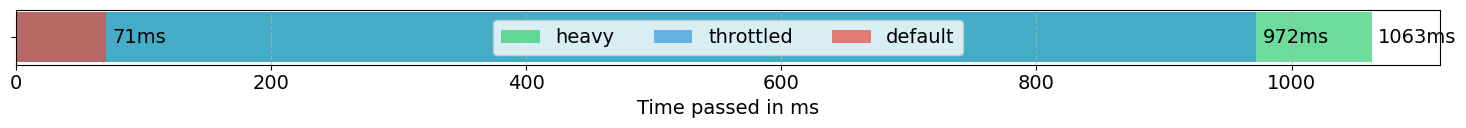

In [26]:
fig, ax = plt.subplots(figsize=(15, 1.5))

fcp_values = [df['fcp'].quantile(0.75) for df in dfs.values()]

bar_height = 0.25
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = []
for i, (name, value) in enumerate(zip(reversed(dfs.keys()), reversed(fcp_values))):
    bar = ax.barh(0.5, value, height=bar_height, 
                 label=name, color=colors[i], alpha=0.7)
    bars.append(bar)

ax.set_yticks([0.5])
ax.set_yticklabels([''])
ax.set_xlabel('Time passed in ms')

ax.grid(True, axis='x', linestyle='--', alpha=0.7)

for i, bar in enumerate(bars):
    width = bar[0].get_width()
    ax.text(width + 5, bar[0].get_y() + bar[0].get_height()/2, 
            f'{fcp_values[-(i+1)]:.0f}ms', 
            va='center')

ax.legend(loc='lower center', ncols=3)

plt.tight_layout()

plt.show()

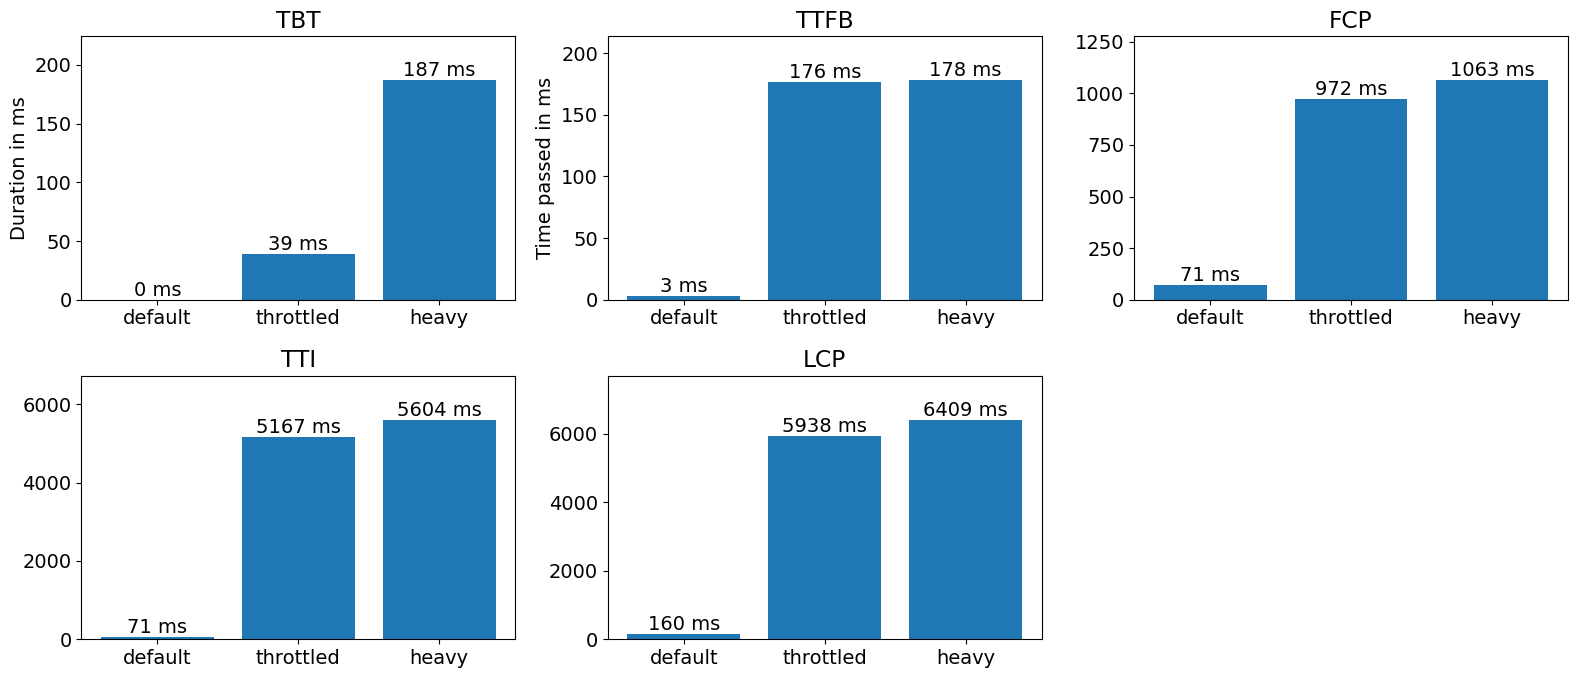

In [27]:
features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(16, 7))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)
axes = axes.flatten()

for idx, feature in enumerate(features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs.keys()}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    
    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        label = f'{int(round(height, 0))} ms'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature.upper())
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms')


for ax in axes[len(target_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Distribution of performance metrics

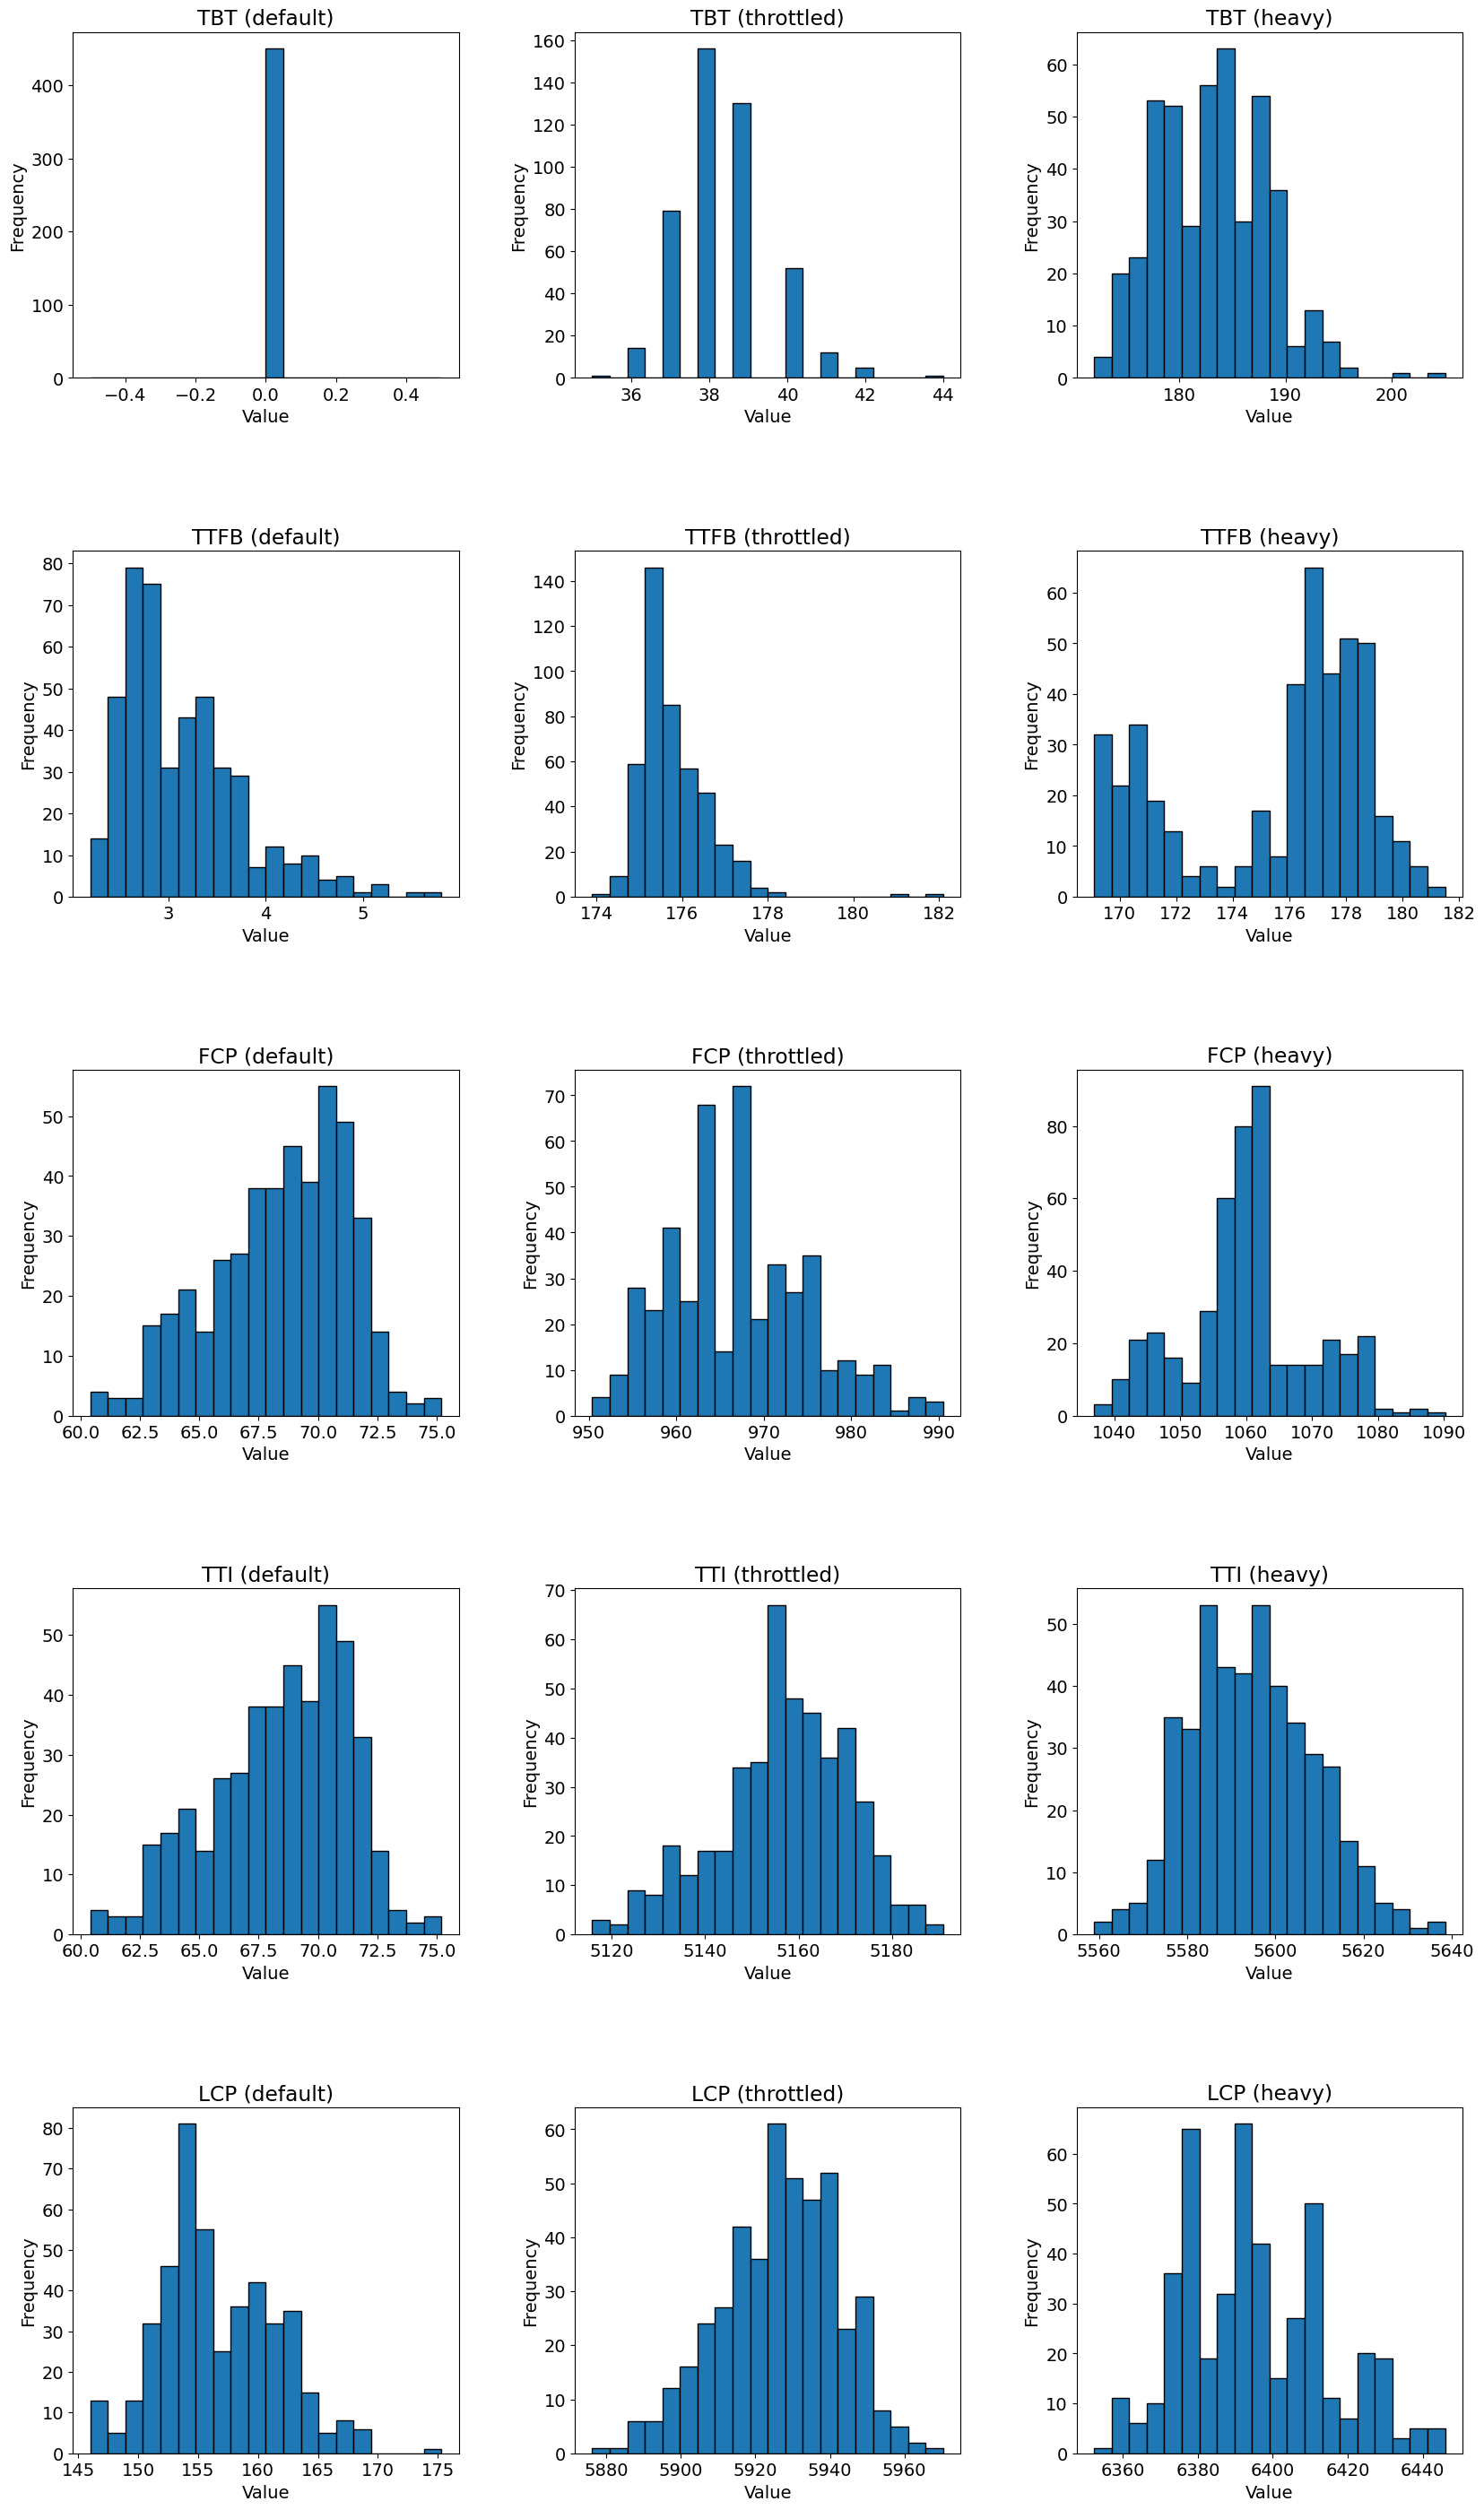

In [28]:
target_features = ['tbt', 'ttfb', 'fcp', 'tti', 'lcp']

fig, axes = plt.subplots(nrows=len(target_features), ncols=len(dfs.keys()), figsize=(20, 6*len(target_features)))
plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.95, bottom=0.05)

for y, f in enumerate(target_features):
    for x, d in enumerate(dfs.keys()):
        axes[y, x].hist(dfs[d][f], bins=20,  edgecolor='black')
        axes[y, x].set_title(f'{f.upper()} ({d})')
        axes[y, x].set_xlabel('Value')
        axes[y, x].set_ylabel('Frequency')

plt.show()

## Details dataset
This dataset kept track of the specific metrics, like the start and end time of the LCP. 

The start-time is defined by the timestamp where the image arrived to the browser (download ready). 

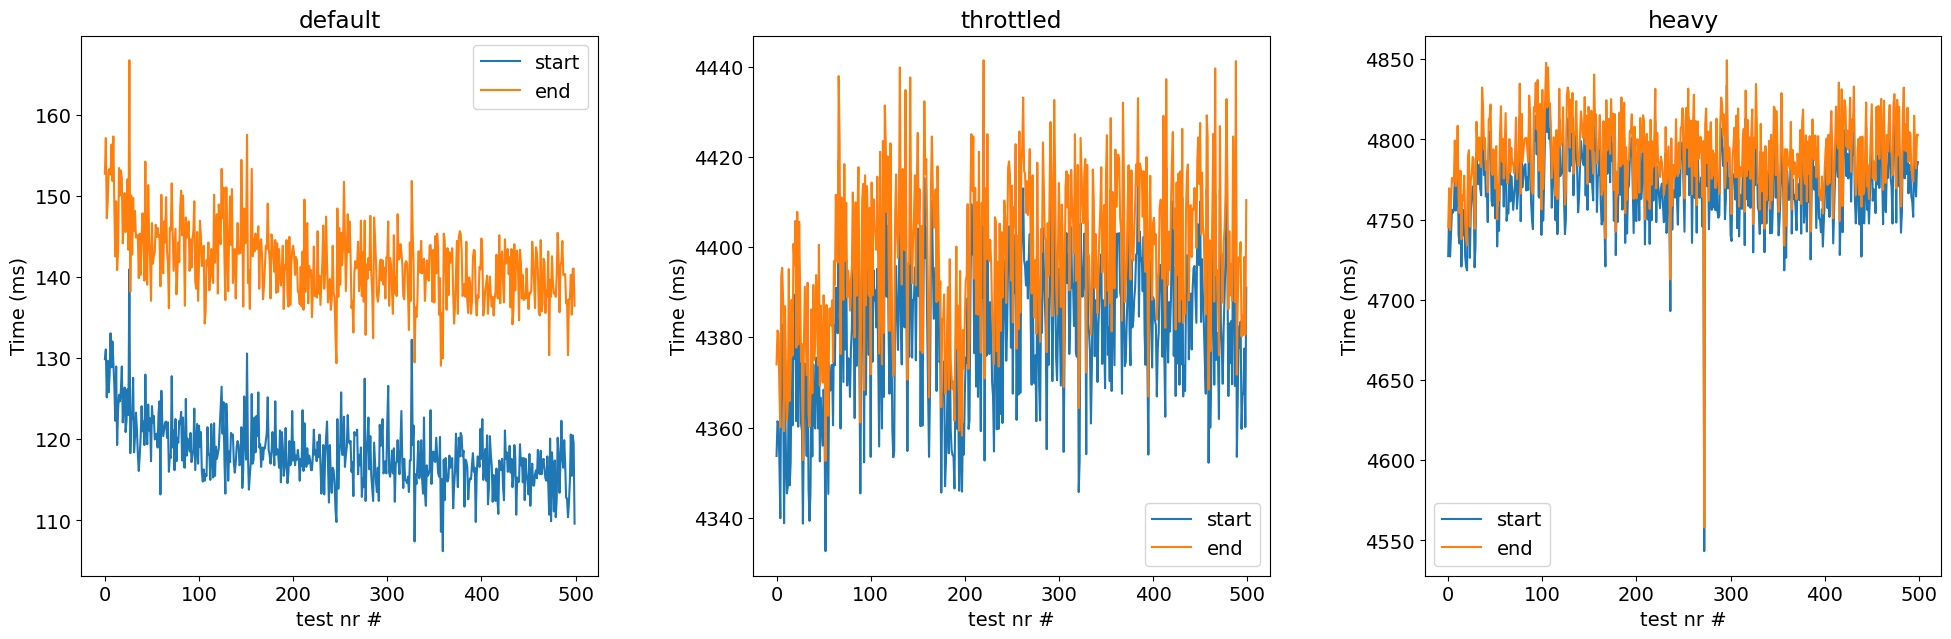

In [29]:
det_df = pd.read_csv(f'{path}details/details-csr-sd.csv', sep=',')
det_df_t = pd.read_csv(f'{path}details/details-csr-sd-throttled.csv', sep=',')
det_df_ht = pd.read_csv(f'{path}details/details-csr-sd-throttled-heavy.csv', sep=',')

lcp_dfs = {
  'default': det_df[(det_df['type'] == 'LCP') & (det_df['idx'] > 5)].reset_index(drop=True),
  'throttled': det_df_t[(det_df_t['type'] == 'LCP') & (det_df_t['idx'] > 5)].reset_index(drop=True),
  'heavy': det_df_ht[(det_df_ht['type'] == 'LCP') & (det_df_ht['idx'] > 5)].reset_index(drop=True),
}
lcp_features = ['start','end','duration','name','element','url','id']


def plot_lcp_line(_df, loc, idx):
  for f in ['start', 'end']:
    loc.plot(_df[f], label=f)
  
  loc.set_title("LCP")
  loc.set_ylabel('Time (ms)')
  loc.set_xlabel('test nr #')
  loc.legend()

graph_row(plot_lcp_line, lcp_dfs, height=6, width=24)
plt.show()